# 01 — Exploratory Data Analysis
**Citi Bike Demand Forecasting & A/B Testing Framework**

This notebook covers:
1. Load & inspect raw trip data (Jan–Mar 2024)
2. Data quality checks
3. Demand patterns — hourly, daily, day-of-week
4. Station-level analysis — top stations, demand distribution
5. User & ride type breakdown
6. Geographic spread
7. Key findings → feeds Phase 2 (clustering) and Phase 3 (forecasting)

In [1]:
import sys
sys.path.append('..')  # so we can import from src/

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data.preprocess import load_zip, clean, build_hourly_demand, add_time_features

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

## 1. Load Raw Data

In [2]:
zip_files = sorted(RAW_DIR.glob('*-citibike-tripdata.zip'))
print(f'Found {len(zip_files)} zip files:')
for f in zip_files:
    print(f'  {f.name}')

Found 3 zip files:
  202401-citibike-tripdata.zip
  202402-citibike-tripdata.zip
  202403-citibike-tripdata.zip


In [3]:
# Load and clean all months
frames = []
for zf in zip_files:
    print(f'Loading {zf.name}...')
    df_raw = load_zip(zf)
    df_clean = clean(df_raw)
    frames.append(df_clean)
    print(f'  {len(df_raw):,} raw → {len(df_clean):,} clean rows')

df = pd.concat(frames, ignore_index=True)
print(f'\nTotal: {len(df):,} trips')

Loading 202401-citibike-tripdata.zip...
  1,888,085 raw → 1,886,318 clean rows
Loading 202402-citibike-tripdata.zip...
  2,121,501 raw → 2,118,975 clean rows
Loading 202403-citibike-tripdata.zip...
  2,663,295 raw → 2,659,659 clean rows

Total: 6,664,952 trips


## 2. Data Quality

In [4]:
print('Shape:', df.shape)
print('\nDate range:', df['started_at'].min(), '→', df['started_at'].max())
print('\nColumn dtypes:')
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

Shape: (6664952, 14)

Date range: 2023-12-31 13:50:28.976000 → 2024-03-31 23:57:16.025000

Column dtypes:
ride_id                          str
rideable_type               category
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id                 str
end_station_name                 str
end_station_id                   str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual               category
duration_min                 float64
dtype: object

Null counts:
ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_name        0
start_station_id          0
end_station_name      10743
end_station_id        10965
start_lat                 0
start_lng                 0
end_lat               10965
end_lng               10965
member_casua

Ride types: {'electric_bike': 4301079, 'classic_bike': 2363873}
Member types: {'member': 5782460, 'casual': 882492}


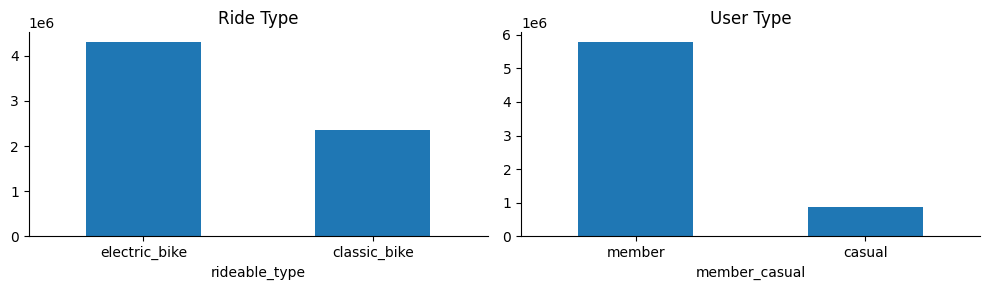

In [5]:
print('Ride types:', df['rideable_type'].value_counts().to_dict())
print('Member types:', df['member_casual'].value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
df['rideable_type'].value_counts().plot(kind='bar', ax=axes[0], title='Ride Type')
df['member_casual'].value_counts().plot(kind='bar', ax=axes[1], title='User Type')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

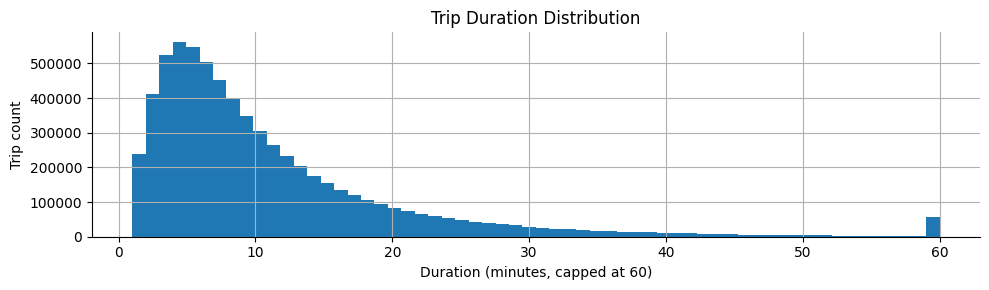

count    6664952.0
mean          11.6
std           20.1
min            1.0
25%            4.8
50%            8.1
75%           13.8
max         1440.0
Name: duration_min, dtype: float64


In [6]:
# Trip duration distribution
fig, ax = plt.subplots(figsize=(10, 3))
df['duration_min'].clip(upper=60).hist(bins=60, ax=ax, edgecolor='none')
ax.set_xlabel('Duration (minutes, capped at 60)')
ax.set_ylabel('Trip count')
ax.set_title('Trip Duration Distribution')
plt.tight_layout()
plt.show()
print(df['duration_min'].describe().round(1))

## 3. Demand Patterns

In [7]:
# Build hourly demand aggregation
hourly = build_hourly_demand(df)
hourly = add_time_features(hourly)
print(f'Station-hour rows: {len(hourly):,}')
print(f'Unique stations: {hourly["station_id"].nunique():,}')
hourly.head()

Station-hour rows: 1,963,864
Unique stations: 2,269


,station_id,hour,trip_count,member_trips,casual_trips,classic_trips,electric_trips,lat,lng,hour_of_day,day_of_week,month,is_weekend
0,190 Morgan,2024-02-23 12:00:00,1,1,0,0,1,40.711072,-73.932096,12,4,2,0
1,2733.03,2024-01-01 14:00:00,3,0,3,0,3,40.633385,-74.016562,14,0,1,0
2,2733.03,2024-01-01 16:00:00,5,5,0,1,4,40.633385,-74.016562,16,0,1,0
3,2733.03,2024-01-01 17:00:00,2,2,0,0,2,40.633385,-74.016562,17,0,1,0
4,2733.03,2024-01-02 07:00:00,1,1,0,0,1,40.633385,-74.016562,7,1,1,0


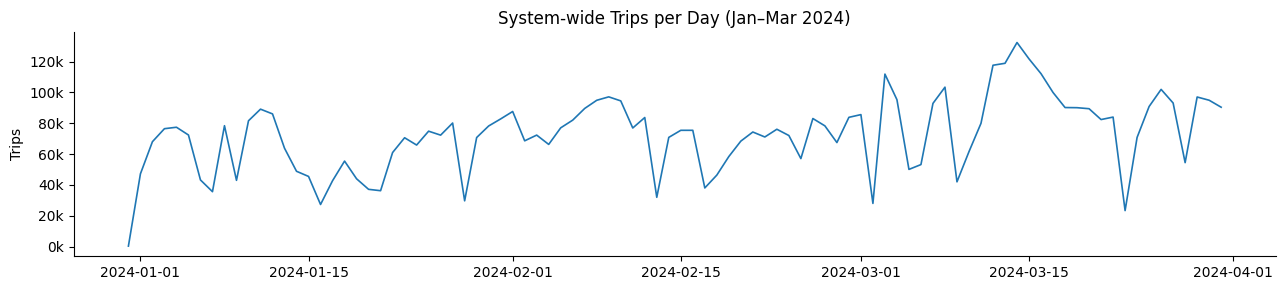

In [8]:
# System-wide trips per day
daily = df.groupby(df['started_at'].dt.date).size().reset_index(name='trips')
daily['started_at'] = pd.to_datetime(daily['started_at'])

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(daily['started_at'], daily['trips'], linewidth=1.2)
ax.set_title('System-wide Trips per Day (Jan–Mar 2024)')
ax.set_ylabel('Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

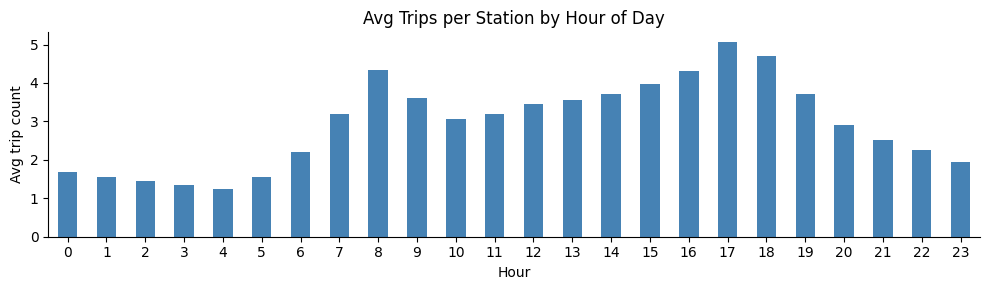

In [9]:
# Average demand by hour of day
by_hour = hourly.groupby('hour_of_day')['trip_count'].mean()

fig, ax = plt.subplots(figsize=(10, 3))
by_hour.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Avg Trips per Station by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg trip count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

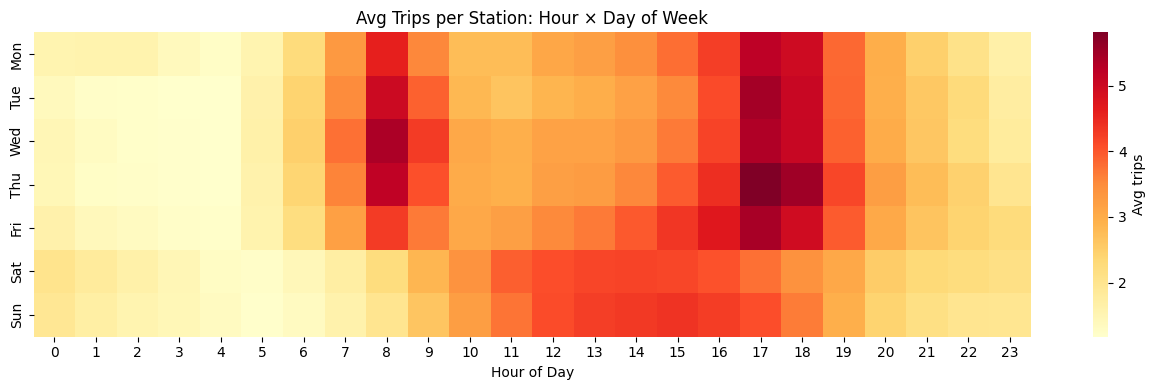

In [10]:
# Heatmap: hour of day vs day of week
pivot = hourly.groupby(['day_of_week', 'hour_of_day'])['trip_count'].mean().unstack()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0,
            yticklabels=day_labels, cbar_kws={'label': 'Avg trips'})
ax.set_title('Avg Trips per Station: Hour × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

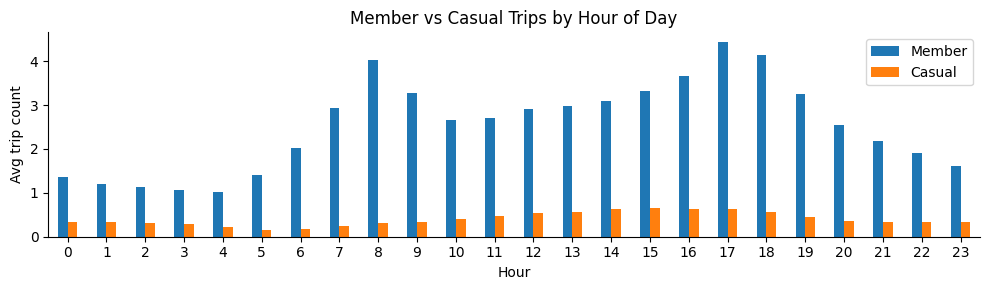

In [11]:
# Member vs Casual by hour of day
by_hour_type = hourly.groupby('hour_of_day')[['member_trips', 'casual_trips']].mean()

fig, ax = plt.subplots(figsize=(10, 3))
by_hour_type.plot(kind='bar', ax=ax, edgecolor='none')
ax.set_title('Member vs Casual Trips by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg trip count')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Member', 'Casual'])
plt.tight_layout()
plt.show()

## 4. Station-Level Analysis

In [12]:
# Total demand per station
station_demand = (
    hourly.groupby('station_id')
    .agg(
        total_trips=('trip_count', 'sum'),
        avg_hourly=('trip_count', 'mean'),
        lat=('lat', 'first'),
        lng=('lng', 'first'),
    )
    .reset_index()
    .sort_values('total_trips', ascending=False)
)

print(f'Total stations: {len(station_demand):,}')
print('\nTop 10 busiest stations:')
print(station_demand.head(10)[['station_id', 'total_trips', 'avg_hourly']].to_string(index=False))

Total stations: 2,269

Top 10 busiest stations:
station_id  total_trips  avg_hourly
   6140.05        28923   15.719022
   6450.05        22766   11.597555
   6822.09        22401   12.004823
   6173.08        21352   12.083758
   5788.13        20873   11.693557
   6331.01        20634   10.685655
   5779.11        19676    9.912343
   6197.08        19384   10.164657
   6602.03        19277   10.264643
   5905.14        19159   10.278433


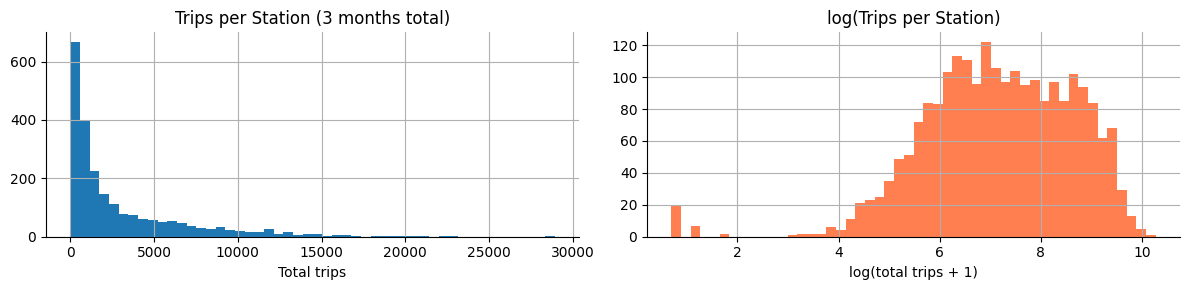

Top 10% of stations account for 40.0% of all trips


In [13]:
# Demand distribution across stations (long tail)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

station_demand['total_trips'].hist(bins=50, ax=axes[0], edgecolor='none')
axes[0].set_title('Trips per Station (3 months total)')
axes[0].set_xlabel('Total trips')

np.log1p(station_demand['total_trips']).hist(bins=50, ax=axes[1], edgecolor='none', color='coral')
axes[1].set_title('log(Trips per Station)')
axes[1].set_xlabel('log(total trips + 1)')

plt.tight_layout()
plt.show()

# What fraction of trips come from top 10% of stations?
top10_pct = station_demand.head(int(len(station_demand) * 0.1))['total_trips'].sum()
total = station_demand['total_trips'].sum()
print(f'Top 10% of stations account for {top10_pct/total:.1%} of all trips')

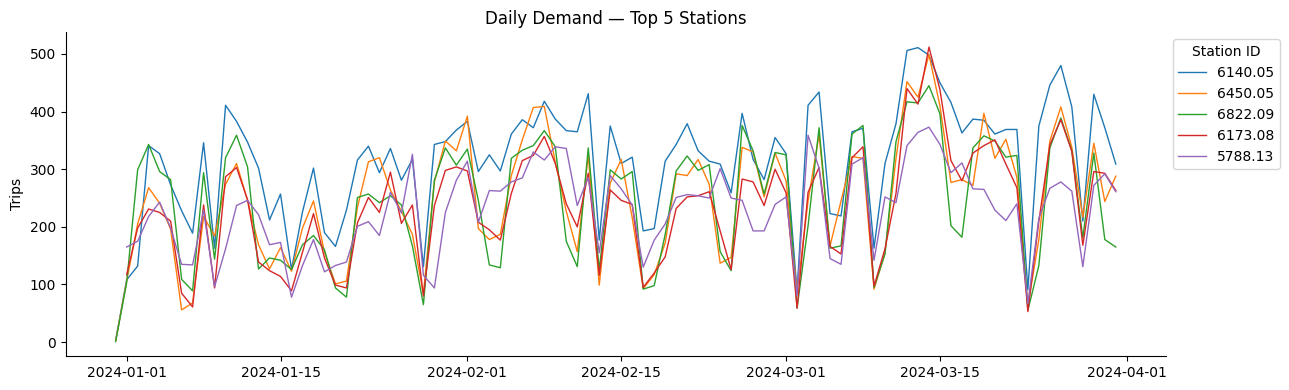

In [14]:
# Time series for top 5 stations
top5_stations = station_demand.head(5)['station_id'].tolist()
top5 = hourly[hourly['station_id'].isin(top5_stations)].copy()

fig, ax = plt.subplots(figsize=(13, 4))
for sid in top5_stations:
    s = top5[top5['station_id'] == sid].sort_values('hour')
    # Daily rollup for readability
    s_daily = s.groupby(s['hour'].dt.date)['trip_count'].sum()
    ax.plot(pd.to_datetime(s_daily.index), s_daily.values, label=sid, linewidth=1)

ax.set_title('Daily Demand — Top 5 Stations')
ax.set_ylabel('Trips')
ax.legend(title='Station ID', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 5. Geographic Spread

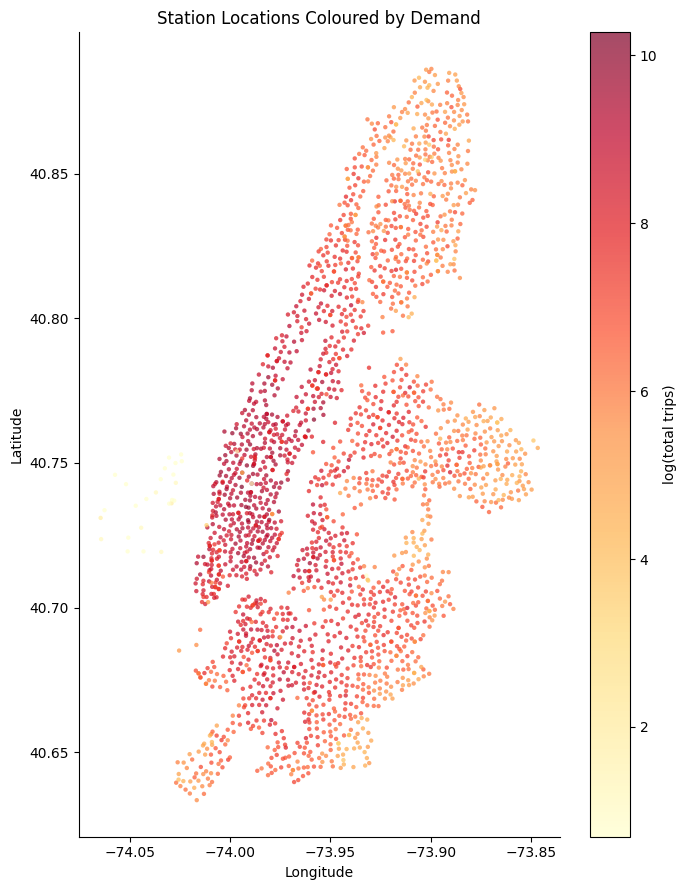

In [15]:
# Scatter of stations coloured by demand
fig, ax = plt.subplots(figsize=(7, 9))
sc = ax.scatter(
    station_demand['lng'],
    station_demand['lat'],
    c=np.log1p(station_demand['total_trips']),
    cmap='YlOrRd',
    s=10,
    alpha=0.7,
    linewidths=0,
)
plt.colorbar(sc, ax=ax, label='log(total trips)')
ax.set_title('Station Locations Coloured by Demand')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [16]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save full hourly demand
out_hourly = PROCESSED_DIR / 'hourly_demand_2024Q1.parquet'
hourly.to_parquet(out_hourly, index=False)
print(f'Saved hourly demand → {out_hourly}  ({len(hourly):,} rows)')

# Save station summary
out_stations = PROCESSED_DIR / 'station_summary_2024Q1.parquet'
station_demand.to_parquet(out_stations, index=False)
print(f'Saved station summary → {out_stations}  ({len(station_demand):,} stations)')

Saved hourly demand → ..\data\processed\hourly_demand_2024Q1.parquet  (1,963,864 rows)
Saved station summary → ..\data\processed\station_summary_2024Q1.parquet  (2,269 stations)


## 7. Key Findings

*(Fill in after running the notebook)*

- **Trip volume:** ~X million trips over Jan–Mar 2024
- **Stations:** ~X active stations
- **Demand is highly skewed:** top 10% of stations = ~X% of trips → strong case for clustering
- **Clear commuter pattern:** dual peaks at 8am and 5–6pm on weekdays; flat on weekends
- **Member vs Casual:** members dominate weekday AM/PM peaks; casuals skew weekend/afternoon
- **Geographic concentration:** highest demand in Midtown / Lower Manhattan + Williamsburg

→ **Next:** `02_clustering.ipynb` — segment stations into commuter / tourist / recreational clusters